In [3]:
from google.colab import files
import pandas as pd

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)
df.head()

Saving Dataset for Data Analytics (1).xlsx to Dataset for Data Analytics (1).xlsx


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
print("Shape:", df.shape)
print("\nColumn Names:\n" , df.columns.tolist())
print("\nData Types:\n" , df.dtypes)
print("\nMissing Values:\n" , df.isnull().sum())

Shape: (1200, 14)

Column Names:
 ['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
 OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing Values:
 OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart   

In [5]:
print("Mean TotalPrice:" , round(df['TotalPrice'] .mean() , 2))
print("Median TotalPrice:" , round(df['TotalPrice'] .median() ,2))
print("Mean Quantity:" , round(df['Quantity'] .mean() ,2))
print("\nFull Stats:\n" , df[['TotalPrice' , 'Quantity' ,'UnitPrice']].describe())

Mean TotalPrice: 1053.97
Median TotalPrice: 823.62
Mean Quantity: 2.95

Full Stats:
         TotalPrice     Quantity    UnitPrice
count  1200.000000  1200.000000  1200.000000
mean   1053.968300     2.945833   356.412750
std     819.856558     1.407557   197.177146
min      11.390000     1.000000    11.390000
25%     410.520000     2.000000   186.062500
50%     823.615000     3.000000   364.210000
75%    1578.475000     4.000000   521.570000
max    3456.400000     5.000000   699.930000


In [6]:
print("Orders by Product:\n" , df['Product'].value_counts())
print("Order Status:\n" , df['OrderStatus'].value_counts())
print("\nTop Referral:\n" , df['ReferralSource'].value_counts)

Orders by Product:
 Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64
Order Status:
 OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Top Referral:
 <bound method IndexOpsMixin.value_counts of 0       Instagram
1        Referral
2           Email
3        Facebook
4           Email
          ...    
1195       Google
1196     Facebook
1197    Instagram
1198    Instagram
1199     Referral
Name: ReferralSource, Length: 1200, dtype: object>


In [7]:
Q1 = df['TotalPrice'] .quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['TotalPrice'] < Q1 - 1.5*IQR) | (df['TotalPrice'] > Q3 + 1.*IQR)]
print("Number of Outliers:" , len(outliers))
print(outliers[['OrderID' , 'Product' , 'TotalPrice']])

Number of Outliers: 53
        OrderID  Product  TotalPrice
0     ORD200000  Monitor     2853.10
2     ORD200002   Tablet     2753.40
10    ORD200010   Tablet     3129.85
86    ORD200086  Printer     3215.15
97    ORD200097   Tablet     3097.60
107   ORD200107  Printer     3353.75
221   ORD200221   Tablet     3196.85
222   ORD200222    Chair     2773.44
223   ORD200223    Phone     2771.64
241   ORD200241    Chair     3078.35
296   ORD200296     Desk     3194.00
326   ORD200326   Laptop     3352.40
328   ORD200328   Tablet     3370.20
361   ORD200361  Printer     3299.25
364   ORD200364    Phone     3143.70
367   ORD200367   Laptop     3293.85
389   ORD200389     Desk     2790.00
450   ORD200450  Monitor     3075.50
463   ORD200463   Laptop     3313.90
469   ORD200469    Chair     3384.90
471   ORD200471     Desk     2756.35
492   ORD200492   Laptop     3032.60
511   ORD200511  Monitor     2876.20
527   ORD200527    Chair     3267.35
540   ORD200540   Laptop     3243.25
578   ORD200578

In [8]:
print("Revenue by Product: \n" , df.groupby('Product')['TotalPrice'] .sum() .sort_values(ascending=False))
print("\nOrder Status: \n" , df['OrderStatus'] .value_counts())
print("\nReferral Source:\n" , df['ReferralSource'] .value_counts())

Revenue by Product: 
 Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

Order Status: 
 OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Referral Source:
 ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


In [9]:
print("Quantity vs TotalPrice:" , round(df['Quantity'] .corr(df['TotalPrice']) ,3))
print("UnitPrice vs TotalPrice:" , round(df['UnitPrice'] .corr(df['TotalPrice']) ,3))

Quantity vs TotalPrice: 0.615
UnitPrice vs TotalPrice: 0.717


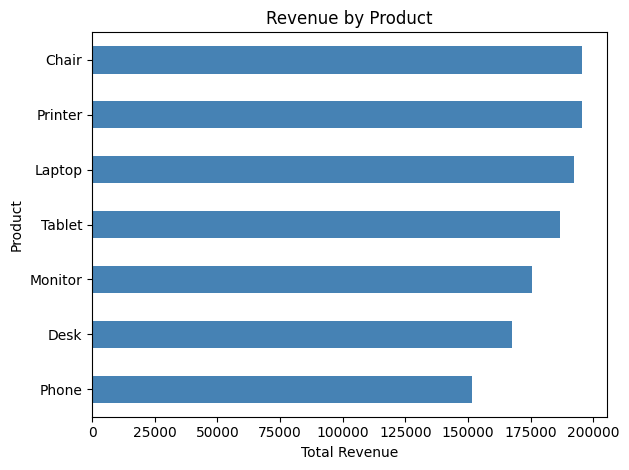

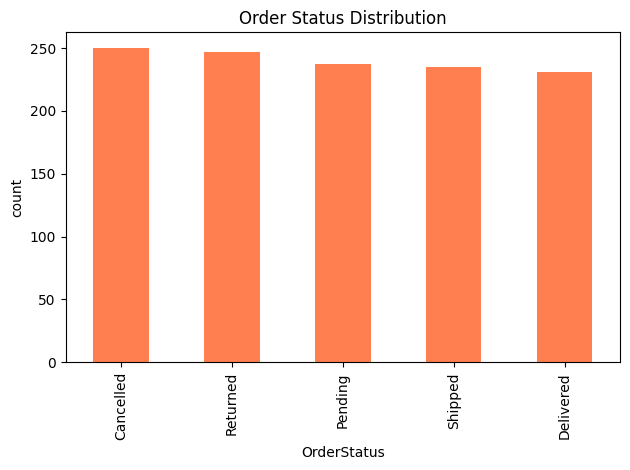

In [12]:
import matplotlib.pyplot as plt

df.groupby('Product')['TotalPrice'] .sum() .sort_values() .plot(kind='barh' , color='steelblue')
plt.title('Revenue by Product')
plt.xlabel('Total Revenue')
plt.tight_layout()
plt.show()

df['OrderStatus'] .value_counts() .plot(kind='bar' ,color='coral')
plt.title('Order Status Distribution')
plt.ylabel('count')
plt.tight_layout()
plt.show()

In [11]:
print("EDA Summary")
print("Total Orders:" , len(df))
print("Mean TotalPrice:" , round(df['TotalPrice'] .mean() ,2))
print("Median TotalPrice:" , round(df['TotalPrice'] .median() ,2))
print("Missing Values - CouponCode: 309")
print("outliers Detected:" ,len(outliers))
print("Top Product by Revenue: Chair")
print("Top Referral Source:" , df['ReferralSource'] .value_counts() .index[0])

EDA Summary
Total Orders: 1200
Mean TotalPrice: 1053.97
Median TotalPrice: 823.62
Missing Values - CouponCode: 309
outliers Detected: 53
Top Product by Revenue: Chair
Top Referral Source: Instagram
